# End-to-end reconstruction with an estimated calibration

Paper reference: §3.3.4 (calibration) → §3.3.6 (reconstruction).

The most realistic simulation in this folder: both the calibration and
the measurement are computed from noisy data. For each noise level:

1. Back-project noisy pixel labels to 3D points on the (unknown) laser
   ray via the known-plane intersection.
2. Estimate $(\boldsymbol{\ell}, \boldsymbol{\alpha})$ from those noisy
   3D points with the paper's `calibrate_laser` (pairwise-difference).
3. Reconstruct the measurement points with that estimated calibration.

Reports the combined calibration + measurement depth error. Also
sweeps the denominator-gating threshold to show the tradeoff between
yield and accuracy near the unobservability distance bounded by
`../max_distance.ipynb`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fishsense_imwut.camera import reconstruct_points, calculate_normals
from fishsense_core.laser import calibrate_laser

## Setup of Simulation
The following reasonable defaults that match the systems we tested against.

In [2]:
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016
FOCAL_LENGTH_PX = 2850

IMAGE_WIDTH, IMAGE_HEIGHT, FOCAL_LENGTH_PX

(4014, 3016, 2850)

In [3]:
camera_intrinsics = np.array([
    [FOCAL_LENGTH_PX, 0, IMAGE_WIDTH / 2],
    [0, FOCAL_LENGTH_PX, IMAGE_HEIGHT / 2],
    [0, 0, 1]
])
inverted_camera_intrinsics = np.linalg.inv(camera_intrinsics)

camera_intrinsics, inverted_camera_intrinsics

(array([[2.850e+03, 0.000e+00, 2.007e+03],
        [0.000e+00, 2.850e+03, 1.508e+03],
        [0.000e+00, 0.000e+00, 1.000e+00]]),
 array([[ 3.50877193e-04,  0.00000000e+00, -7.04210526e-01],
        [ 0.00000000e+00,  3.50877193e-04, -5.29122807e-01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]))

In [4]:
laser_position = np.array([-0.04, -0.11, 0])
laser_direction = np.array([1e-10, 1e-10, 1])

laser_params = np.concatenate([laser_direction, laser_position[:2]])

laser_position, laser_direction, laser_params

(array([-0.04, -0.11,  0.  ]),
 array([1.e-10, 1.e-10, 1.e+00]),
 array([ 1.0e-10,  1.0e-10,  1.0e+00, -4.0e-02, -1.1e-01]))

**Ground-truth laser pose.** Packed as a 5-vector $(\alpha_x, \alpha_y, \alpha_z, \ell_x, \ell_y)$. Unlike the other reconstruction notebooks, **this one does *not* use the true pose** — it re-estimates the pose from the same noisy observations before reconstructing, combining both error sources.

## Next we setup data we can use for testing

In [5]:
STEP_COUNT = 1000
t = np.linspace(0.5, 30, STEP_COUNT)

STEP_COUNT, t

(1000,
 array([ 0.5       ,  0.52952953,  0.55905906,  0.58858859,  0.61811812,
         0.64764765,  0.67717718,  0.70670671,  0.73623624,  0.76576577,
         0.7952953 ,  0.82482482,  0.85435435,  0.88388388,  0.91341341,
         0.94294294,  0.97247247,  1.002002  ,  1.03153153,  1.06106106,
         1.09059059,  1.12012012,  1.14964965,  1.17917918,  1.20870871,
         1.23823824,  1.26776777,  1.2972973 ,  1.32682683,  1.35635636,
         1.38588589,  1.41541542,  1.44494494,  1.47447447,  1.504004  ,
         1.53353353,  1.56306306,  1.59259259,  1.62212212,  1.65165165,
         1.68118118,  1.71071071,  1.74024024,  1.76976977,  1.7992993 ,
         1.82882883,  1.85835836,  1.88788789,  1.91741742,  1.94694695,
         1.97647648,  2.00600601,  2.03553554,  2.06506507,  2.09459459,
         2.12412412,  2.15365365,  2.18318318,  2.21271271,  2.24224224,
         2.27177177,  2.3013013 ,  2.33083083,  2.36036036,  2.38988989,
         2.41941942,  2.44894895,  2.4784784

In [6]:
p = laser_position[:, np.newaxis] + t[np.newaxis, :] * laser_direction[:, np.newaxis]

p

array([[-0.04      , -0.04      , -0.04      , ..., -0.04      ,
        -0.04      , -0.04      ],
       [-0.11      , -0.11      , -0.11      , ..., -0.11      ,
        -0.11      , -0.11      ],
       [ 0.5       ,  0.52952953,  0.55905906, ..., 29.94094094,
        29.97047047, 30.        ]], shape=(3, 1000))

In [7]:
s = p / p[2, :]
s = camera_intrinsics @ s

s

array([[1.77900000e+03, 1.79171456e+03, 1.80308594e+03, ...,
        2.00319250e+03, 2.00319626e+03, 2.00320000e+03],
       [8.81000000e+02, 9.15965029e+02, 9.47236348e+02, ...,
        1.49752939e+03, 1.49753970e+03, 1.49755000e+03],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]], shape=(3, 1000))

In [8]:
s_pixel = np.round(s)

s_pixel

array([[1.779e+03, 1.792e+03, 1.803e+03, ..., 2.003e+03, 2.003e+03,
        2.003e+03],
       [8.810e+02, 9.160e+02, 9.470e+02, ..., 1.498e+03, 1.498e+03,
        1.498e+03],
       [1.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 1.000e+00,
        1.000e+00]], shape=(3, 1000))

In [9]:
normals = calculate_normals(p)

normals

array([[ 0.85771824,  0.1945646 ,  0.47588238],
       [-0.72840603, -0.6070528 ,  0.31766579],
       [-0.98191181,  0.15642695,  0.10667619],
       ...,
       [-0.93512886,  0.33491811,  0.11560225],
       [-0.13968815, -0.90752299,  0.39609248],
       [ 0.15638433,  0.98552139,  0.06550972]], shape=(1000, 3))

**End-to-end sweep.** For each pixel-noise level: add noise to `s`, back-project through random plane normals (Equation 9) to get noisy 3D calibration points, run `calibrate_laser` (paper's pairwise-difference) to get an *estimated* pose, and reconstruct the original measurement pixels using **that estimated pose** via Equation 5. The reported $z$-error therefore captures the **compounded** effect of calibration error *and* measurement error.

**Gating threshold sweep.** The final cell sweeps $\epsilon$ on the reconstruction denominator using `calculate_max_distance` (from `../max_distance.ipynb`) to translate each threshold into a useful-range limit.

In [10]:
np.random.seed(0)

calibrations_by_stds = []
stds = [
    (0.0, 0.0),
    (0.5, 0.5),
    (1.0, 1.0),
    (2.0, 2.0),
    (3.0, 5.0), # Real world estimate
    (5.0, 5.0),
    (8.0, 8.0),
    (10.0, 10.0),
]

z_errors_by_stds = []
for idx, (x_std, y_std) in enumerate(stds):
    s_noisy = s.copy()
    s_noisy[0, :] += np.random.normal(0, x_std, s.shape[1])
    s_noisy[1, :] += np.random.normal(0, y_std, s.shape[1])

    rays = inverted_camera_intrinsics @ s_noisy
    scale_factor = np.einsum('ij,ij->j', normals.T, p) / np.einsum('ij,ij->j', normals.T, rays)
    p_noisy = rays * scale_factor
    
    local_laser_origin, local_laser_orientation = calibrate_laser(p_noisy.T)
    p_reconstructed, _ = reconstruct_points(s_noisy, inverted_camera_intrinsics, local_laser_origin, local_laser_orientation)

    z_error = np.abs(p_reconstructed[2, :] - p[2, :]) / p[2, :] * 100
    z_errors_by_stds.append(((x_std, y_std), z_error))

/tmp/ipykernel_569610/1328154728.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + [f"{x_std},{y_std}" for x_std, y_std in stds])


Text(0, 0.5, 'Z Percent Error (%)')

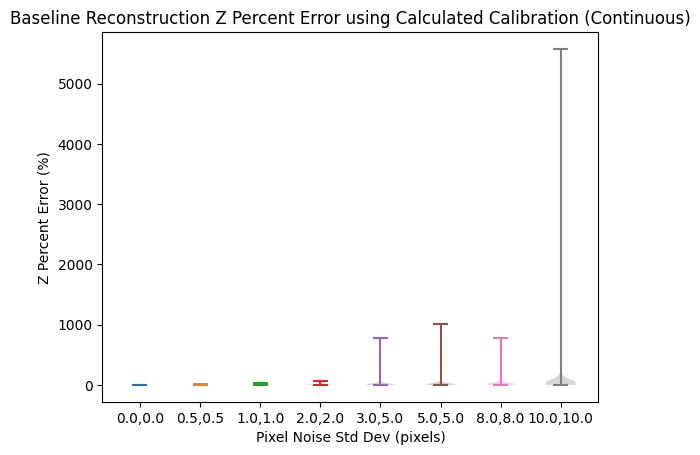

In [11]:
fig, ax = plt.subplots()

for idx, ((x_std, y_std), z_error) in enumerate(z_errors_by_stds):
    ax.violinplot(z_error, positions=[idx])

ax.set_xticklabels([""] + [f"{x_std},{y_std}" for x_std, y_std in stds])
ax.set_title("Baseline Reconstruction Z Percent Error using Calculated Calibration (Continuous)")
ax.set_xlabel("Pixel Noise Std Dev (pixels)")
ax.set_ylabel("Z Percent Error (%)")

/tmp/ipykernel_569610/4012488129.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + [f"{x_std},{y_std}" for x_std, y_std in stds[:5]])


Text(0, 0.5, 'Z Percent Error (%)')

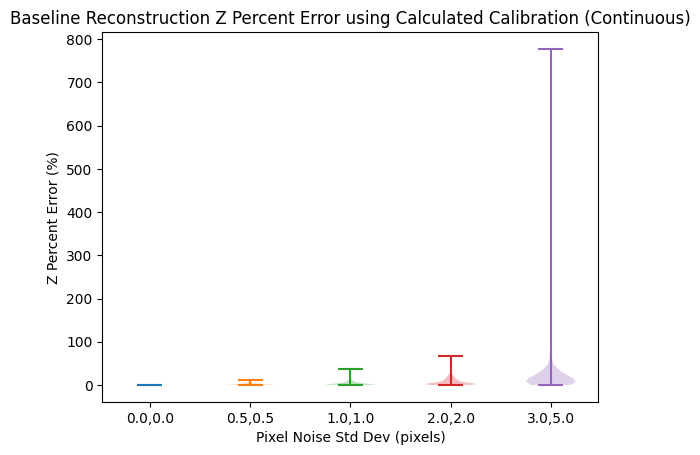

In [12]:
fig, ax = plt.subplots()

for idx, ((x_std, y_std), z_error) in enumerate(z_errors_by_stds[:5]):
    ax.violinplot(z_error, positions=[idx])

ax.set_xticklabels([""] + [f"{x_std},{y_std}" for x_std, y_std in stds[:5]])
ax.set_title("Baseline Reconstruction Z Percent Error using Calculated Calibration (Continuous)")
ax.set_xlabel("Pixel Noise Std Dev (pixels)")
ax.set_ylabel("Z Percent Error (%)")

In [13]:
def calculate_max_distance(laser_position, laser_direction, epsilon=1e-4):
    s0 = laser_direction @ laser_position
    sv = laser_direction @ laser_direction
    n0 = laser_position @ laser_position
    nv = 2 * (laser_direction @ laser_position)
    vv = laser_direction @ laser_direction

    A = (1 - epsilon) * sv - sv ** 2
    B = (1 - epsilon) * nv - 2 * s0 * sv
    C = (1 - epsilon) * n0 - s0 ** 2

    t1 = (-B + np.sqrt(B**2 - 4 * A * C)) / (2 * A)
    t2 = (-B - np.sqrt(B**2 - 4 * A * C)) / (2 * A)

    z1 = t1 * laser_direction[2] + laser_position[2]
    z2 = t2 * laser_direction[2] + laser_position[2]

    return max(z1, z2)

(999,)
278.2555735002684 11.143939213542819 17.869689448278482
(957,)
106.18804678940145 10.514857446033414 15.12822134356637
(401,)
41.02246104790353 5.217188841765555 8.156651127459487
(185,)
15.761604300755378 2.4139618123997986 3.4589323737303257
(107,)
11.75246125492311 1.6629051877726095 2.156998015054453
(24,)
2.5260605907281453 0.71804330328502 0.941360424464143


/tmp/ipykernel_569610/3631111117.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + [f"{denom_thresh:.0e} with max distance {calculate_max_distance(laser_position, laser_direction, epsilon=denom_thresh):.2f}m" for denom_thresh in thresholds])


Text(0.5, 1.0, 'Reconstruction Z Percent Error vs Gating Threshold (Calculated Calibration, 5px Noise)')

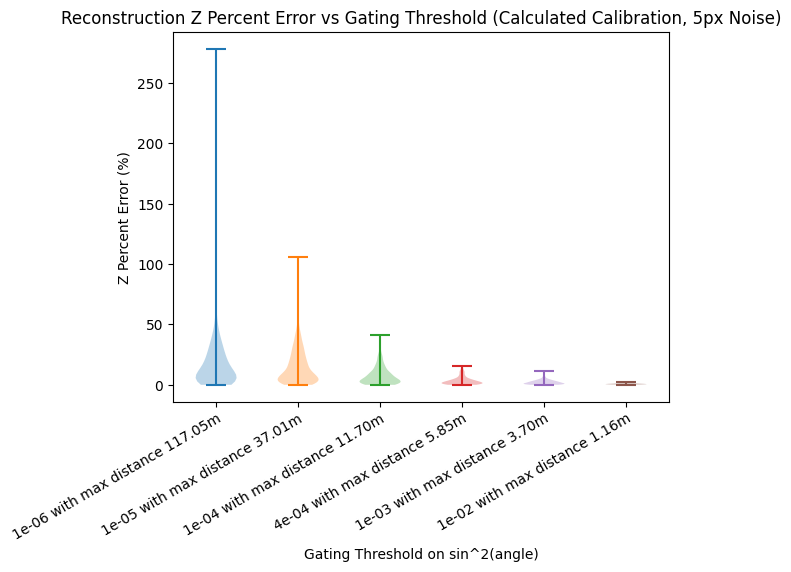

In [14]:
np.random.seed(0)
fig, ax = plt.subplots()

(x_std, y_std), _ = z_errors_by_stds[5]
thresholds = [1e-6, 1e-5, 1e-4, 4e-4, 1e-3, 1e-2]
    
s_noisy = s.copy()
s_noisy[0, :] += np.random.normal(0, x_std, s.shape[1])
s_noisy[1, :] += np.random.normal(0, y_std, s.shape[1])

rays = inverted_camera_intrinsics @ s_noisy
scale_factor = np.einsum('ij,ij->j', normals.T, p) / np.einsum('ij,ij->j', normals.T, rays)
p_noisy = rays * scale_factor

local_laser_origin, local_laser_orientation = calibrate_laser(p_noisy.T)

p_reconstructed, denom = reconstruct_points(s_noisy, inverted_camera_intrinsics, local_laser_origin, local_laser_orientation)

for idx, denom_thresh in enumerate(thresholds):
    filtered = np.where(denom > denom_thresh)[0]
    print(filtered.shape)
    z_error = np.abs(p_reconstructed[2, filtered] - p[2, filtered]) / p[2, filtered] * 100

    print(np.max(z_error), np.median(z_error), np.mean(z_error))

    ax.violinplot(z_error, positions=[idx])

ax.set_xticklabels([""] + [f"{denom_thresh:.0e} with max distance {calculate_max_distance(laser_position, laser_direction, epsilon=denom_thresh):.2f}m" for denom_thresh in thresholds])
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
ax.set_ylabel("Z Percent Error (%)")
ax.set_xlabel("Gating Threshold on sin^2(angle)")
ax.set_title("Reconstruction Z Percent Error vs Gating Threshold (Calculated Calibration, 5px Noise)")